<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Machine Learning
### Sommersemester 2026
Prof. Dr. Stefan Goetze

##  Multi-Layer Perceptron mit Keras

Für dieses Aufgabenblatt benötigen wir die Bibliothek [Keras](https://keras.io/).  
Seit Version 1.4 von [Tensorflow](https://www.tensorflow.org/) ist Keras Teil der TensorFlow Core API und kann damit direkt aus dem Framework hinaus genutzt werden.
Fall Sie TensorFlow noch nicht installiert haben, sollten Sie das nun erledigen, z.B. über den Paketmanager *pip*.

In [55]:
try:
    import tensorflow as tf
except:
    import sys
    print("Trying to install tensorflow...")
    !{sys.executable} -m pip install tensorflow
    #import sys
    #!conda install --yes --prefix {sys.prefix} -c conda-forge tensorflow
    import tensorflow as tf

In [56]:
print("Lade Tensorflow in Version", tf.__version__)
from packaging import version
assert version.parse(tf.__version__) > version.parse("2.3.0"), "TF 2.3.0 hat einen Bug beim Speichern und Laden von Modellen. Siehe [2]"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import urllib.request

Lade Tensorflow in Version 2.21.0


In diesem Aufgabenblatt wollen wir ein recht einfaches Klassifikationsproblem einmal mit logistischer Regression (mit *Scikit-learn*) und dann mit einem Multi-Layer Perceptron (MLP) mit der Keras Sequential API untersuchen.
Der Datensatz enthält knapp 15.000 Einträge aus einer Mitarbeiter-Datenbank.
Die darin enthaltenen Informationen geben z.B. Auskunft darüber, wie lange eine Person schon in der Firma ist, wie hoch die Gehaltsstufe ist oder zufrieden die Person im Betrieb ist.
Als Label wollen wir die Information verwenden, ob die Person die Firma verlassen hat.

In [57]:
url = "https://github.com/fhswf/datasets/raw/main/MA.csv"
dfile = "./MA.csv"

if not os.path.isfile(dfile):
    urllib.request.urlretrieve(url, dfile)

data=pd.read_csv('MA.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zufriedenheit         14999 non-null  float64
 1   Letzte_Evaluation     14999 non-null  float64
 2   Anzahl_Projekte       14999 non-null  int64  
 3   Mittlere_Arbeitszeit  14999 non-null  int64  
 4   Dienstjahre           14999 non-null  int64  
 5   Arbeitsunfall_in_2J   14999 non-null  int64  
 6   Firma_verlassen       14999 non-null  int64  
 7   Befoerderung_in_5J    14999 non-null  int64  
 8   Bereich               14999 non-null  str    
 9   Gehalt                14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [58]:
data.head(10)

,Zufriedenheit,Letzte_Evaluation,Anzahl_Projekte,Mittlere_Arbeitszeit,Dienstjahre,Arbeitsunfall_in_2J,Firma_verlassen,Befoerderung_in_5J,Bereich,Gehalt
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


Wir sehen, dass die meisten Merkmale numerisch sind, nur *Bereich* und *Gehalt* sind kategorisch.
Die Spalte Gehalt hat allerdings eine Sortierung, d.h. wir habe es hier eigentlich mit einem *ordinalen* Merkmal zu tun.
Daher übersetzen wir die Klassen (*high*, *low*, und *medium*) in ganze Zahlen.

In [59]:
df = data.copy()
df['Gehalt'] = pd.Categorical(df['Gehalt'], categories=['high', 'medium', 'low']) # Weißt den Datentyp "Kategorie" zu
df['Gehalt'] = df.Gehalt.cat.codes

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Zufriedenheit         14999 non-null  float64
 1   Letzte_Evaluation     14999 non-null  float64
 2   Anzahl_Projekte       14999 non-null  int64  
 3   Mittlere_Arbeitszeit  14999 non-null  int64  
 4   Dienstjahre           14999 non-null  int64  
 5   Arbeitsunfall_in_2J   14999 non-null  int64  
 6   Firma_verlassen       14999 non-null  int64  
 7   Befoerderung_in_5J    14999 non-null  int64  
 8   Bereich               14999 non-null  str    
 9   Gehalt                14999 non-null  int8   
dtypes: float64(2), int64(6), int8(1), str(1)
memory usage: 1.0 MB


In [61]:
df.head(10)

,Zufriedenheit,Letzte_Evaluation,Anzahl_Projekte,Mittlere_Arbeitszeit,Dienstjahre,Arbeitsunfall_in_2J,Firma_verlassen,Befoerderung_in_5J,Bereich,Gehalt
0,0.38,0.53,2,157,3,0,1,0,sales,2
1,0.80,0.86,5,262,6,0,1,0,sales,1
2,0.11,0.88,7,272,4,0,1,0,sales,1
3,0.72,0.87,5,223,5,0,1,0,sales,2
4,0.37,0.52,2,159,3,0,1,0,sales,2
5,0.41,0.50,2,153,3,0,1,0,sales,2
6,0.10,0.77,6,247,4,0,1,0,sales,2
7,0.92,0.85,5,259,5,0,1,0,sales,2
8,0.89,1.00,5,224,5,0,1,0,sales,2
9,0.42,0.53,2,142,3,0,1,0,sales,2


<div class="alert alert-block alert-info">
    
**Aufgabe: Transformieren Sie das Merkmal "Bereich" per One-Hot-Kodierung in numerische Merkmale. Selektieren Sie als Labels `y` die Spalte `Firma_verlassen` aus dem Datensatz. Der Datensatz `X` soll alle Spalten bis auf die Labels enthalten.**

*Hinweis:* Für die One-hot-Kodierung können Sie die Funktion [`pandas.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) verwenden.
</div>

In [62]:
from sklearn.preprocessing import OneHotEncoder

oneHot = OneHotEncoder(sparse_output=False)
oneHotEncoded = oneHot.fit_transform(df[['Bereich']])
oneHotEncodedDF = pd.DataFrame(
    oneHotEncoded,
    columns=oneHot.get_feature_names_out(['Bereich']), # feature_names_in_ is used, but if none exist values are generated
    index=df.index,
)

df = pd.concat(
    [df.drop(columns=['Bereich']), oneHotEncodedDF],
    axis=1,
)

X = df.drop(columns=['Firma_verlassen'])

y = df['Firma_verlassen']

print('Dimensions of training data X and labels y:')
X.shape, y.shape

Dimensions of training data X and labels y:


((14999, 18), (14999,))

In [63]:
assert X.shape == (14999, 18)
assert y.shape == (14999,)

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

FEATURES = X_train.shape[1]
X_train.shape, X_test.shape

((10499, 18), (4500, 18))

In [65]:
df.head(10)

,Zufriedenheit,Letzte_Evaluation,Anzahl_Projekte,Mittlere_Arbeitszeit,Dienstjahre,Arbeitsunfall_in_2J,Firma_verlassen,Befoerderung_in_5J,Gehalt,Bereich_IT,Bereich_RandD,Bereich_accounting,Bereich_hr,Bereich_management,Bereich_marketing,Bereich_product_mng,Bereich_sales,Bereich_support,Bereich_technical
0,0.38,0.53,2,157,3,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.80,0.86,5,262,6,0,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.11,0.88,7,272,4,0,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.72,0.87,5,223,5,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.37,0.52,2,159,3,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,0.41,0.50,2,153,3,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,0.10,0.77,6,247,4,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,0.92,0.85,5,259,5,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.89,1.00,5,224,5,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,0.42,0.53,2,142,3,0,1,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


<div class="alert alert-block alert-info">
    
**Aufgabe: Standardisieren Sie die Merkmale in `X`.**

*Hinweis:* Sie können dazu die Klasse `StandardScale` aus `sklearn import preprocessing` verwenden.
</div>

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [67]:
assert all(np.isclose(X_train.mean(axis=0), 0, atol=1e-3))

<div class="alert alert-block alert-info">   
    
**Aufgabe: Trainieren Sie ein Logistic Regression Modell mit den Trainingsdaten. Berechnen Sie die Accuracy `ca` für die Testdaten.**

</div>

In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

ca = model.score(X_test, y_test)

print("Accuracy = %.2f%%" % (ca*100))

Accuracy = 78.89%


In [69]:
assert np.isclose(ca, 0.78, atol=1e-2)

### MLP mit Keras

Wir wollen nun für die gleichen Daten ein Multi-Layer Perzeptron mit Keras aufstellen.

In [70]:
y = df.Firma_verlassen
X = df.drop(['Firma_verlassen'], axis=1)
X.shape, y.shape


((14999, 18), (14999,))

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


<div class="alert alert-block alert-info">   
    
**Aufgabe: Stellen Sie nun ein sequentielles Keras Modell auf. Es soll mindestens 3 Schichten haben. Als Aktivierungsfunktion verwenden Sie `sigmoid`.**

</div>

In [72]:
#Modell definieren
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(FEATURES,)))

model.add(tf.keras.layers.Dense(100, activation='sigmoid'))
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))


In [73]:
assert len(model.layers)>2, "Das Modell soll mindestens 3 Schichten haben"

Nun erzeugen wir das Modell mit der Funktion `compile`. Dabei geben wir das Optimierungsverfahren, die (Art der) Kostenfunktion sowie die zu berechnenden Metriken an.

<div class="alert alert-block alert-info">   
    
**Aufgabe: Wählen Sie eine geeignet Kostenfunktion aus. Als Metrik soll die Accuracy berechnet werden.**

</div>

In [74]:
#Modell erzeugen
optimizer = 'sgd'
loss = 'sparse_categorical_crossentropy'
metrics = ['accuracy']


model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [75]:
assert model.trainable

Nun trainieren wir das Modell und geben die Accuracy für die Testdaten aus.

In [76]:
#Modell trainieren
history = model.fit(X_train, y_train, epochs=20, validation_split=0.3)

#Trainiertes Modell auswerten
test_loss, test_acc = model.evaluate (X_test, y_test)
print('Test accuracy:', test_acc)

Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7385 - loss: 0.9304 - val_accuracy: 0.7600 - val_loss: 0.5846
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7628 - loss: 0.5698 - val_accuracy: 0.7600 - val_loss: 0.5651
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7628 - loss: 0.5592 - val_accuracy: 0.7600 - val_loss: 0.5593
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7628 - loss: 0.5552 - val_accuracy: 0.7600 - val_loss: 0.5581
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7628 - loss: 0.5534 - val_accuracy: 0.7600 - val_loss: 0.5578
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7628 - loss: 0.5521 - val_accuracy: 0.7600 - val_loss: 0.5540
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7628 - loss: 0.5509 - val_accuracy: 0.7600 - val_loss: 0.5544
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7628 - loss: 0.5507 - val_accuracy: 0.

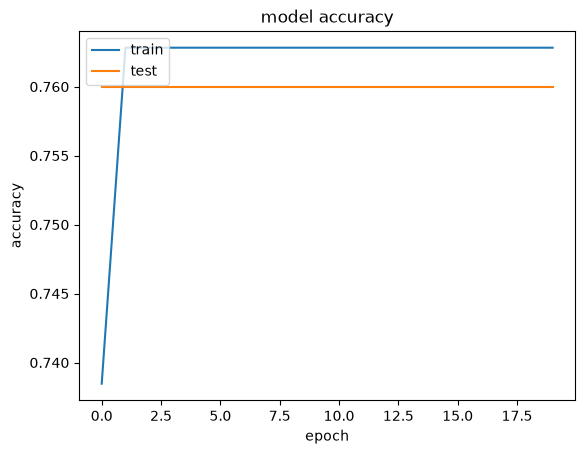

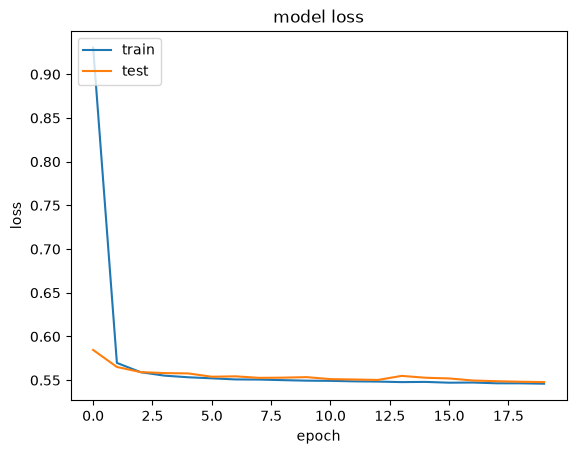

In [77]:
import matplotlib.pyplot as plt
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left') # Das Label Test ist hier falsch. Es wird die validierungsdaten geprüft. Die Testdaten werden erst im Anschluss geprüft und niregendwo geplottet. 
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Modell ähnlich gute Ergebnisse erzielt, wie die logistische Regression, diese Ergebnisse aber durch weitere Optimierungschritte nicht mehr verbessert werden.
Sie können nun versuchen, die Ergebnisse durch Ändern des Modells zu verbessern, etwa durch die Verwendung einer anderen Aktivierungsfunktion, die ein schnelleres Lernverahlten aufweist (z.B. `tanh`).

In [78]:
# YOUR CODE HERE

# Tatsächlich nicht gemacht aufgrund von Zeitgründen. 

### Hausnummern erkennen

Wir wollen daher noch einen Weiteren Datensatz betrachten, der deutlich komplexer ist.
Es handelt sich um Fotos, bzw. um Bildausschnitte die einzelne Ziffern von Hausnummern zeigen.
Damit ähneln die Daten dem MNIST Datensatz.
Da es sich um (Farb-) Fotos handelt, die zudem noch recht verrauscht sind, ist das Problem, die Ziffern zu erkennen, aber deutlich schwieriger.

Wir laden zunächst die Bidler von der URL http://ufldl.stanford.edu/housenumbers herunter.
Details zum Datensatz finden Sie in [1].

In [79]:
import pandas as pd
import os
import tarfile
import urllib.request


url = [f"http://ufldl.stanford.edu/housenumbers/{n}_32x32.mat" for n in ("train", "test")]
dfile = [f"./{n}_32x32.mat" for n in ("train", "test")]


for i in range(len(url)):
    if not os.path.isfile(dfile[i]):
        print('Starting download of file ' + dfile[i] + ' from ' + url[i])
        urllib.request.urlretrieve(url[i], dfile[i])
        print('Downloaded file ' + dfile[i] + ' from ' + url[i])

Die Daten liegen im `.mat`-Format vor, dass zumeist in Matlab verwendet wird.
Wir importieren die Daten über die Funktion `scipy.io.loadmat` und extrahieren dann die Attribute und Labels jeweils aus den Test- und Trainings-Daten.

In [80]:
from scipy.io import loadmat
train_raw = loadmat('./train_32x32.mat')
test_raw = loadmat('./test_32x32.mat')
                   
train_images = np.array(train_raw['X'])
test_images = np.array(test_raw['X'])

print(np.info(train_images), end="\n\n")

train_labels = train_raw['y']
test_labels = test_raw['y']
                   
print(train_images.shape)
print(test_images.shape)

class:  ndarray
shape:  (32, 32, 3, 73257)
strides:  (1, 32, 1024, 3072)
itemsize:  1
aligned:  True
contiguous:  False
fortran:  True
data pointer: 0x2462e313040
byteorder:  little
byteswap:  False
type: uint8
None

(32, 32, 3, 73257)
(32, 32, 3, 26032)


Wenn Sie sich die Dimension der Datensätze ansehen, stellen Sie fest, dass die Daten unpassend strukturiert sind.
In den ersten Dimensionen haben wir die (RGB) Pixel der einzelnen Bilder, in der letzten Dimension die einzelnen Bilder.
Daher sortieren wir die Dimensionen, bzw. die Axen unserer Datensätze um, sodass die erste Dimension dem Index eines Bildes entspricht.

In [81]:
# Fix the axes of the images

train_images = np.moveaxis(train_images, -1, 0)
test_images = np.moveaxis(test_images, -1, 0)

print(train_images.shape)
print(test_images.shape)

(73257, 32, 32, 3)
(26032, 32, 32, 3)


Nun können wir ein zufälliges Bild ausgeben:

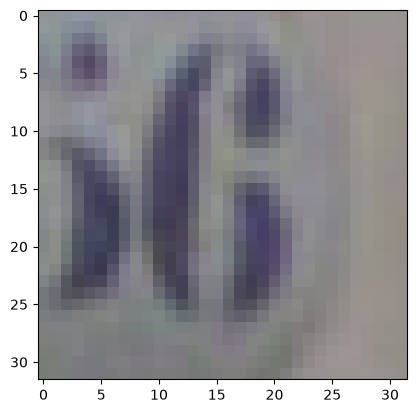

Label:  [6]
[[[144 150 150]
  [143 148 151]
  [140 148 156]
  ...
  [151 149 145]
  [153 149 145]
  [153 146 144]]

 [[143 153 151]
  [141 150 151]
  [134 143 151]
  ...
  [153 148 144]
  [154 148 145]
  [153 147 145]]

 [[138 148 150]
  [138 148 148]
  [127 135 145]
  ...
  [155 147 144]
  [155 147 145]
  [154 148 145]]

 ...

 [[124 125 121]
  [122 124 120]
  [124 125 128]
  ...
  [148 142 136]
  [148 142 136]
  [146 143 135]]

 [[120 125 118]
  [121 126 119]
  [122 126 127]
  ...
  [150 144 138]
  [148 143 137]
  [147 143 135]]

 [[119 124 119]
  [120 126 121]
  [120 125 124]
  ...
  [153 147 144]
  [151 146 141]
  [148 144 139]]]


In [82]:
import matplotlib.pyplot as plt
import random 
# Plot a random image and its label

random_index = random.randint(0,len(train_images))

plt.imshow(train_images[random_index])
plt.show()

print('Label: ', train_labels[random_index])
print(train_images[random_index])

In [83]:
train_images = train_images.astype('float64')
test_images = test_images.astype('float64')

train_labels = train_labels.astype('int64')
test_labels = test_labels.astype('int64')

train_images /= 255.0
test_images /= 255.0

train_labels -= 1
test_labels -= 1

In [84]:
assert test_labels.max()==9, """Die Label stimmen nicht.
Das kann passieren, wenn Sie eine Zelle doppelt ausgeführt haben.
Importieren Sie den Datensatz noch einmal"""

<div class="alert alert-block alert-info">   
    
**Aufgabe: Stellen Sie ein sequenziellen Keras Model auf. Das Modell soll 2 Schichten haben.
Die erste Schicht soll 128 Neuronen besitzen und ReLU als Aktivierungsfunktion verwenden.
Die zweite Schicht soll 10 Neuronen besitzen und als Aktivierungsfunktion die Softmax-Funktion verwenden.
Bei der Eingabeschicht orientieren Sie sich am besten an den MNIST Beispielen für Keras.**

</div>

In [85]:
#Modell definieren

from pathlib import Path


model_path = Path('my_model.keras')

def create_model():
    if model_path.exists():
        tf.keras.models.load_model(model_path)


    model = tf.keras.Sequential()
    # YOUR CODE HERE
    model.add(tf.keras.layers.Input(shape=[32, 32, 3]))
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))    
    return model

model = create_model()

c:\Users\schue\Documents\LocalRepos\aki-ml\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [86]:
assert len(model.layers) == 3, "Das Model soll eine Input Schicht und 2 Hidden Layers besitzen"
assert model.layers[-2].units == 128
assert model.layers[-1].units == 10

In [87]:
print(test_labels[0])

[4]


<div class="alert alert-block alert-info">   
    
**Aufgabe: Wählen Sie geeignete Parameter für das Modell aus**

</div>

In [88]:
#Modellparameter
optimizer ='adam'
loss = 'categorical_crossentropy'
metrics = ['accuracy']
# From : https://www.kaggle.com/code/mdriponmiah/cnn-svhn-street-view-housing-number-digit#8.1.-Primary-Model


#Modell erzeugen
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)


In [89]:
assert model.trainable

In [90]:
# Transform the train and test labels into one hot encoded

oneHotEncoder = OneHotEncoder(sparse_output=False)

train_labels_one_hot_encoded  = oneHotEncoder.fit_transform(train_labels)
test_labels_one_hot_encoded = oneHotEncoder.transform(test_labels)
print(f"Old label: {train_labels[0]}. New encoded value: {train_labels_one_hot_encoded[0]}")

Old label: [0]. New encoded value: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Nun können wir das Modell trainieren.

In [91]:
#Modell trainieren
history = model.fit(train_images, train_labels_one_hot_encoded, epochs=5)

Epoch 1/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1904 - loss: 2.2433
Epoch 2/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2070 - loss: 2.1282
Epoch 3/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2316 - loss: 2.0726
Epoch 4/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2385 - loss: 2.0593
Epoch 5/5
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2442 - loss: 2.0489


In [92]:
#Trainiertes Modell auswerten
test_loss, test_acc = model.evaluate (test_images, test_labels_one_hot_encoded)
print('Test accuracy:', test_acc)

814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2525 - loss: 2.0731
Test accuracy: 0.2524969279766083


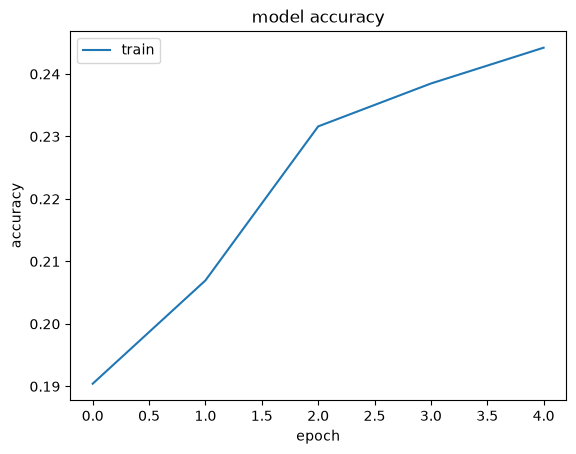

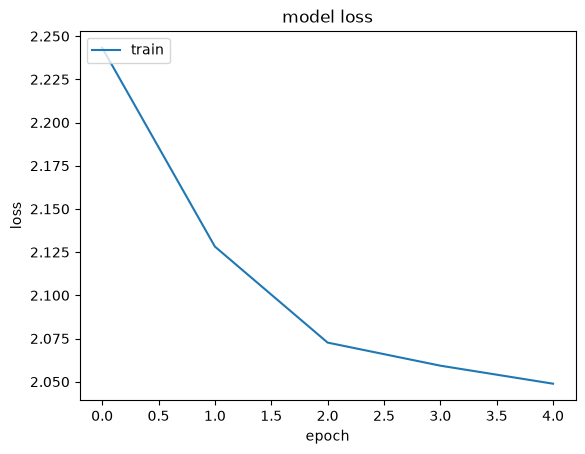

In [93]:
import matplotlib.pyplot as plt
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Den Kurven der Accuracy und der Kostenfunktion nach zu urteilen, kann das Modell noch weiter verbesser werden.
Um bei gleichen (Hyper-)Parametern das Modell nicht immer neu trainieren zu müssen ist es sinnvoll, die Modellparameter in einer Datei zu speichern.

<div class="alert alert-block alert-info">   
    
**Aufgabe:**

1. **Schreiben Sie den Code von oben so um, dass nur dann ein Modell erzeugt wird, wenn im aktuellen Verzeichnis kein Verzeichnis  `my_model` existiert. Wenn Sie existiert, soll das Modell aus diesem Verzeichnis geladen werden.**
1. **Fitten Sie das Modell über 5 Epochen und speichern Sie das Modell danach unter dem Namen `my_model` im TensorFlow SavedModel Format.**<br> *Hinweis: Wenn sie die Methode `save()` auf dem Keras Modell aufrufen, ist das SavedModel Format der Standard*
1. **Wenn Sie die Code-Zelle erneut ausführen, sollten das vortrainierte Model weiterverwendet werden**
1. **Beobachten Sie, ob sich die Accuracy auf den Testdaten verbessert.**
*Hinweis: Sie können die Methoden `keras.models.load_model` und `save` zum Laden und Speichern des Modells verwenden*

</div>

In [94]:

mname = "my_model.tf"

## Switching to new keras format. 

model.save('my_model.keras')



In [96]:
#Trainiertes Modell auswerten
test_loss, test_acc = model.evaluate (test_images, test_labels_one_hot_encoded)
print('Test accuracy:', test_acc)

814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2525 - loss: 2.0731
Test accuracy: 0.2524969279766083


### Referenzen

[1] Yuval Netzer, Tao Wang, Adam Coates, Alessandro Bissacco, Bo Wu, Andrew Y. Ng. *"Reading Digits in Natural Images with Unsupervised Feature Learning"*,  NIPS Workshop on Deep Learning and Unsupervised Feature Learning 2011.

[2] Tensorflow Github Issue #42459 [Accuracy is lost after save/load #42459](https://github.com/tensorflow/tensorflow/issues/42459)

Beiträge zu diesem Notebook: [Heiner Giefers](https://github.com/hgiefers), [Stefan Goetze](https://github.com/Stefan-Goe)
